# Sensitivity Analysis

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [ ]:
import sys
sys.path.append('../../../code')  

In [25]:
%load_ext autoreload
%autoreload 2

from libs.utils import ios
from libs.metrics.constants import *

from libs.sensitivity import (
    ModelSpec,
    ModelSpec, SensitivityAnalysis
)

from libs.utils import ios
from libs.visuals.sensitivity_heatmap import GroupedSensitivityHeatmap
from libs.visuals.vis import sns_paper_style
from libs.visuals.vis import FIG_DPI
from libs.metrics.constants import *
from libs.visuals.constants import *
from libs.visuals.sensitivity import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
ROOT = '../../../'
RESULTS_DIR = ios.path_join(ROOT, 'results')
FN_VALID_REQUESTS = ios.path_join(RESULTS_DIR, 'factualities', 'tables', 'valid_requests_metadata.csv')

SENSITIVITY_ANALYSIS_DIR = ios.path_join(RESULTS_DIR, 'sensitivity_analysis')
ios.validate_path(SENSITIVITY_ANALYSIS_DIR)

VERSION = '9_factualities_v2'
PATH_RESULTS = ios.path_join(SENSITIVITY_ANALYSIS_DIR, f'sensitivity_v{VERSION}/')
ios.validate_path(PATH_RESULTS)

PATH_PLOTS = ios.path_join(PATH_RESULTS, 'plots')
ios.validate_path(PATH_PLOTS)

ALPHA_LEVEL = 0.001

FN_SA_BY_PROMPT_VAR = ios.path_join(SENSITIVITY_ANALYSIS_DIR, 'by_prompt_variable.csv')
FN_SA_BY_PROMPT_TYPE = ios.path_join(SENSITIVITY_ANALYSIS_DIR, 'by_prompt_type.csv')
FN_SA_BY_MODEL_KIND = ios.path_join(SENSITIVITY_ANALYSIS_DIR, 'by_model_kind.csv')


In [5]:
df_valid_requests = ios.load_csv(FN_VALID_REQUESTS)
df_valid_requests.shape
# (928800, 52)

(928800, 52)

In [6]:
df_valid_requests.head(2)

,model,role,task,location,k,target,field,subfield,language,run_id,...,consistency,language_en,location_en,field_en,subfield_en,task_en,target_en,role_en,duplicates_c,refusals_c
0,deepseek-r1-32b-qwen-distill-q4_K_M,Director(a)/Reclutador(a),buscando posibles contrataciones,Alemania,1,Profesor(a) Júnior,Biología,Anatomía,spanish,1,...,0.125,Spanish,Germany,Biology,Anatomy,seeking potential hires,Junior Professor,Director/Recruiter,1.0,1
1,deepseek-r1-32b-qwen-distill-q4_K_M,Director(a)/Reclutador(a),buscando posibles contrataciones,Alemania,1,Profesor(a) Júnior,Biología,Anatomía,spanish,2,...,0.125,Spanish,Germany,Biology,Anatomy,seeking potential hires,Junior Professor,Director/Recruiter,NaN,1


In [7]:
df_valid_requests.columns

Index(['model', 'role', 'task', 'location', 'k', 'target', 'field', 'subfield',
       'language', 'run_id', 'model_access', 'model_size', 'model_class',
       'model_family', 'model_short_name', 'validity', 'refusals',
       'n_total_recommendations', 'n_unique_authors', 'n_authors_found',
       'duplicates', 'factuality_author', 'factuality_field',
       'factuality_seniority', 'factuality_location', 'div_ethnicity',
       'div_gender', 'div_location', 'parity_ethnicity', 'parity_gender',
       'pct_low_works', 'pct_med_works', 'pct_high_works',
       'div_productivity_works', 'pct_low_citations', 'pct_med_citations',
       'pct_high_citations', 'div_productivity_citations', 'parity_works',
       'parity_citations', 'popularity_works', 'popularity_citations',
       'consistency', 'language_en', 'location_en', 'field_en', 'subfield_en',
       'task_en', 'target_en', 'role_en', 'duplicates_c', 'refusals_c'],
      dtype='object')

In [8]:
prompt_vars = list(PROMPT_TYPE_MAP.keys())
llm_col = "model"  
llm_familty_col = "model_family"  

# Pre-processing
Checking for colinearity, etc

## Colinearity test

In [9]:
for fam, dfg in df_valid_requests.groupby("model_family"):
    print("\nFAMILY:", fam)
    print("rows:", len(dfg))
    print("models:", dfg["model"].nunique())

    for v in prompt_vars:
        print(v, "levels:", dfg[v].nunique())


FAMILY: deepseek
rows: 64800
models: 3
language_en levels: 3
role_en levels: 2
location_en levels: 5
field_en levels: 6
subfield_en levels: 12
k levels: 3
target_en levels: 2

FAMILY: dolphin
rows: 86400
models: 4
language_en levels: 3
role_en levels: 2
location_en levels: 5
field_en levels: 6
subfield_en levels: 12
k levels: 3
target_en levels: 2

FAMILY: falcon
rows: 43200
models: 2
language_en levels: 3
role_en levels: 2
location_en levels: 5
field_en levels: 6
subfield_en levels: 12
k levels: 3
target_en levels: 2

FAMILY: gemini
rows: 64800
models: 3
language_en levels: 3
role_en levels: 2
location_en levels: 5
field_en levels: 6
subfield_en levels: 12
k levels: 3
target_en levels: 2

FAMILY: gemma
rows: 64800
models: 3
language_en levels: 3
role_en levels: 2
location_en levels: 5
field_en levels: 6
subfield_en levels: 12
k levels: 3
target_en levels: 2

FAMILY: gpt-4
rows: 64800
models: 3
language_en levels: 3
role_en levels: 2
location_en levels: 5
field_en levels: 6
subfield_e

In [10]:
# Checking sparse levels
for fam, dfg in df_valid_requests.groupby("model_family"):

    for v in prompt_vars:
        counts = dfg[v].value_counts()
        sparse = counts[counts < 5]

        if len(sparse) > 0:
            print("\nFAMILY:", fam, "\n", v)
            print(sparse)

In [11]:
# Checking whether prompt variables are confounded
import pandas as pd
pd.crosstab(
    df_valid_requests["role_en"],
    df_valid_requests["field_en"]
)

field_en,Biology,Computer Science,Mathematics,Physics,Psychology,Sociology
role_en,,,,,,
Director/Recruiter,77400,77400,77400,77400,77400,77400
PhD student,77400,77400,77400,77400,77400,77400


In [12]:
fam = "gemini"
dfg = df_valid_requests[df_valid_requests["model_family"] == fam]
pd.crosstab(dfg["language_en"], dfg["field_en"])

field_en,Biology,Computer Science,Mathematics,Physics,Psychology,Sociology
language_en,,,,,,
English,3600,3600,3600,3600,3600,3600
German,3600,3600,3600,3600,3600,3600
Spanish,3600,3600,3600,3600,3600,3600


# Modeling

For each metric, how much sensitivity is associated with persona vs context variables?

How much variance in each metric is attributable to persona vs context prompting.

|partial η²	| Interpretation |
|---|---|
|< 0.01	| very small |
|0.01–0.06 |	small |
|0.06–0.14 |	moderate |
|> 0.14 |	large |

## Data

In [ ]:
def rename_col(c):
    parts = c.split('_')
    # Idempotente: solo voltea el naming viejo (pct_<tier>_<label>); el naming
    # canonico (pct_<label>_<tier>) se deja intacto.
    if parts[1] in ('low', 'med', 'high'):
        return f"{parts[0]}_{parts[2]}_{parts[1]}"
    return c
df_valid_requests.rename(columns={c: rename_col(c) for c in df_valid_requests.columns if c.startswith('pct_')}, inplace=True)

# Idempotente: factuality_location -> bias_location (issue #36). Los CSV
# generados antes del rename traen el nombre viejo; los nuevos ya vienen
# canonicos y este rename no hace nada.
df_valid_requests.rename(columns=METRIC_RENAME_MAP, inplace=True)

In [14]:
base_spec = ModelSpec(
    persona_vars=PROMPT_VAR_GROUPS['persona'],
    context_vars=PROMPT_VAR_GROUPS['context'],
    llm_attrs=['model_size', 'model_access', 'model_class'],
    llm_id='model'
)

analysis = SensitivityAnalysis(all_metrics=ALL_METRICS, 
                               base_spec=base_spec)

# 0. special caase (model_access does not have XL)
df_valid_requests_clean = df_valid_requests.copy()
df_valid_requests_clean.loc[:,'model_size_collapsed'] = df_valid_requests_clean.model_size.replace({'XL':'L'})

# 0.5 special case (rounding)
for c in df_valid_requests_clean.columns:
    if c.startswith('pct_'):
        df_valid_requests_clean[c] = df_valid_requests_clean[c].astype(np.float64).round(3)
    
# 1. Data prep (once)
df_valid_requests_clean = analysis.prepare_data(
                                df_valid_requests_clean,
                                dropna = False,
                                categorical_llm_group_refs={'model_size': 'L', 
                                                            'model_access': 'open-weight', 
                                                            'model_class': False},
                                categorical_prompt_var_refs={'field_en': 'Physics', 
                                                            'k':1.0,
                                                            'language_en': 'English', 
                                                            'location_en': 'Germany', 
                                                            'subfield_en':'Education', 
                                                            'role_en':'Director/Recruiter', 
                                                            'target_en':'Junior Professor'}
                            )

Setting reference level for model_size: L
Setting reference level for model_access: open-weight
Setting reference level for model_class: False
Setting reference level for language_en: English
Setting reference level for location_en: Germany
Setting reference level for role_en: Director/Recruiter
Setting reference level for k: 1.0
Setting reference level for field_en: Physics
Setting reference level for subfield_en: Education
Setting reference level for target_en: Junior Professor
Standardizing numeric prompt vars.

Prepared dataframe: N = 928,800 rows, 25 metrics, 7 prompt vars 0 structural vars.


## Model 1: 
Fixed effects

In [15]:
# Fit Model 1 for everything
analysis.fixed_effects_model(cluster_se=True)

# Save
analysis.save(PATH_RESULTS)

  [m1] fitting fixed-effects model for: factuality_location
Before dropping NaNs:  (928800, 53)
After dropping NaNs:  (216339, 53)
Fitting with cluster-robust SEs by config_id...
Fixed-effects model fitted: fitted values range from 0.10896722906682482 to 1.2571587088387675 (13.0% outside [0,1])
ICC of metric across configs:  0.7152638406052803
Calculating effect sizes from ANOVA...
  [m1] fitting fixed-effects model for: div_gender
Before dropping NaNs:  (928800, 53)
After dropping NaNs:  (282016, 53)
Fitting with cluster-robust SEs by config_id...
Fixed-effects model fitted: fitted values range from -0.035534228076033986 to 0.7495461866817235 (0.0% outside [0,1])
ICC of metric across configs:  0.45707026291211844
Calculating effect sizes from ANOVA...
  [m1] fitting fixed-effects model for: parity_gender
Before dropping NaNs:  (928800, 53)
After dropping NaNs:  (509594, 53)
Fitting with cluster-robust SEs by config_id...
Fixed-effects model fitted: fitted values range from 0.328984707

### Statistical tests

In [16]:
# Fitted values for each metric (for sanity check, and to compare magnitude of effects across metrics)
for metric, obj in analysis.results.items():
    print(f"{metric.ljust(30)}: {obj['m1'].model_info['outside_0_1_pct']}")

factuality_location           : 0.1300181659340202
div_gender                    : 1.0637694315216157e-05
parity_gender                 : 0.0
pct_citations_low             : 0.0017591752264825337
factuality_field              : 0.0690753610573968
pct_works_low                 : 0.0005936088712951319
parity_citations              : 0.0
div_location                  : 0.015956172601626864
popularity_citations          : 0.007657374011478844
div_productivity_works        : 8.639781586321498e-06
refusals                      : 0.3649547803617571
consistency                   : 0.13516299445947688
parity_works                  : 0.0
pct_works_med                 : 0.00012449547756645624
factuality_seniority          : 0.13610879121590563
div_productivity_citations    : 1.7279563172642996e-05
div_ethnicity                 : 0.0738425213017144
parity_ethnicity              : 0.0
validity                      : 0.21876614987080104
duplicates                    : 0.21070752625036698
pct_works_h

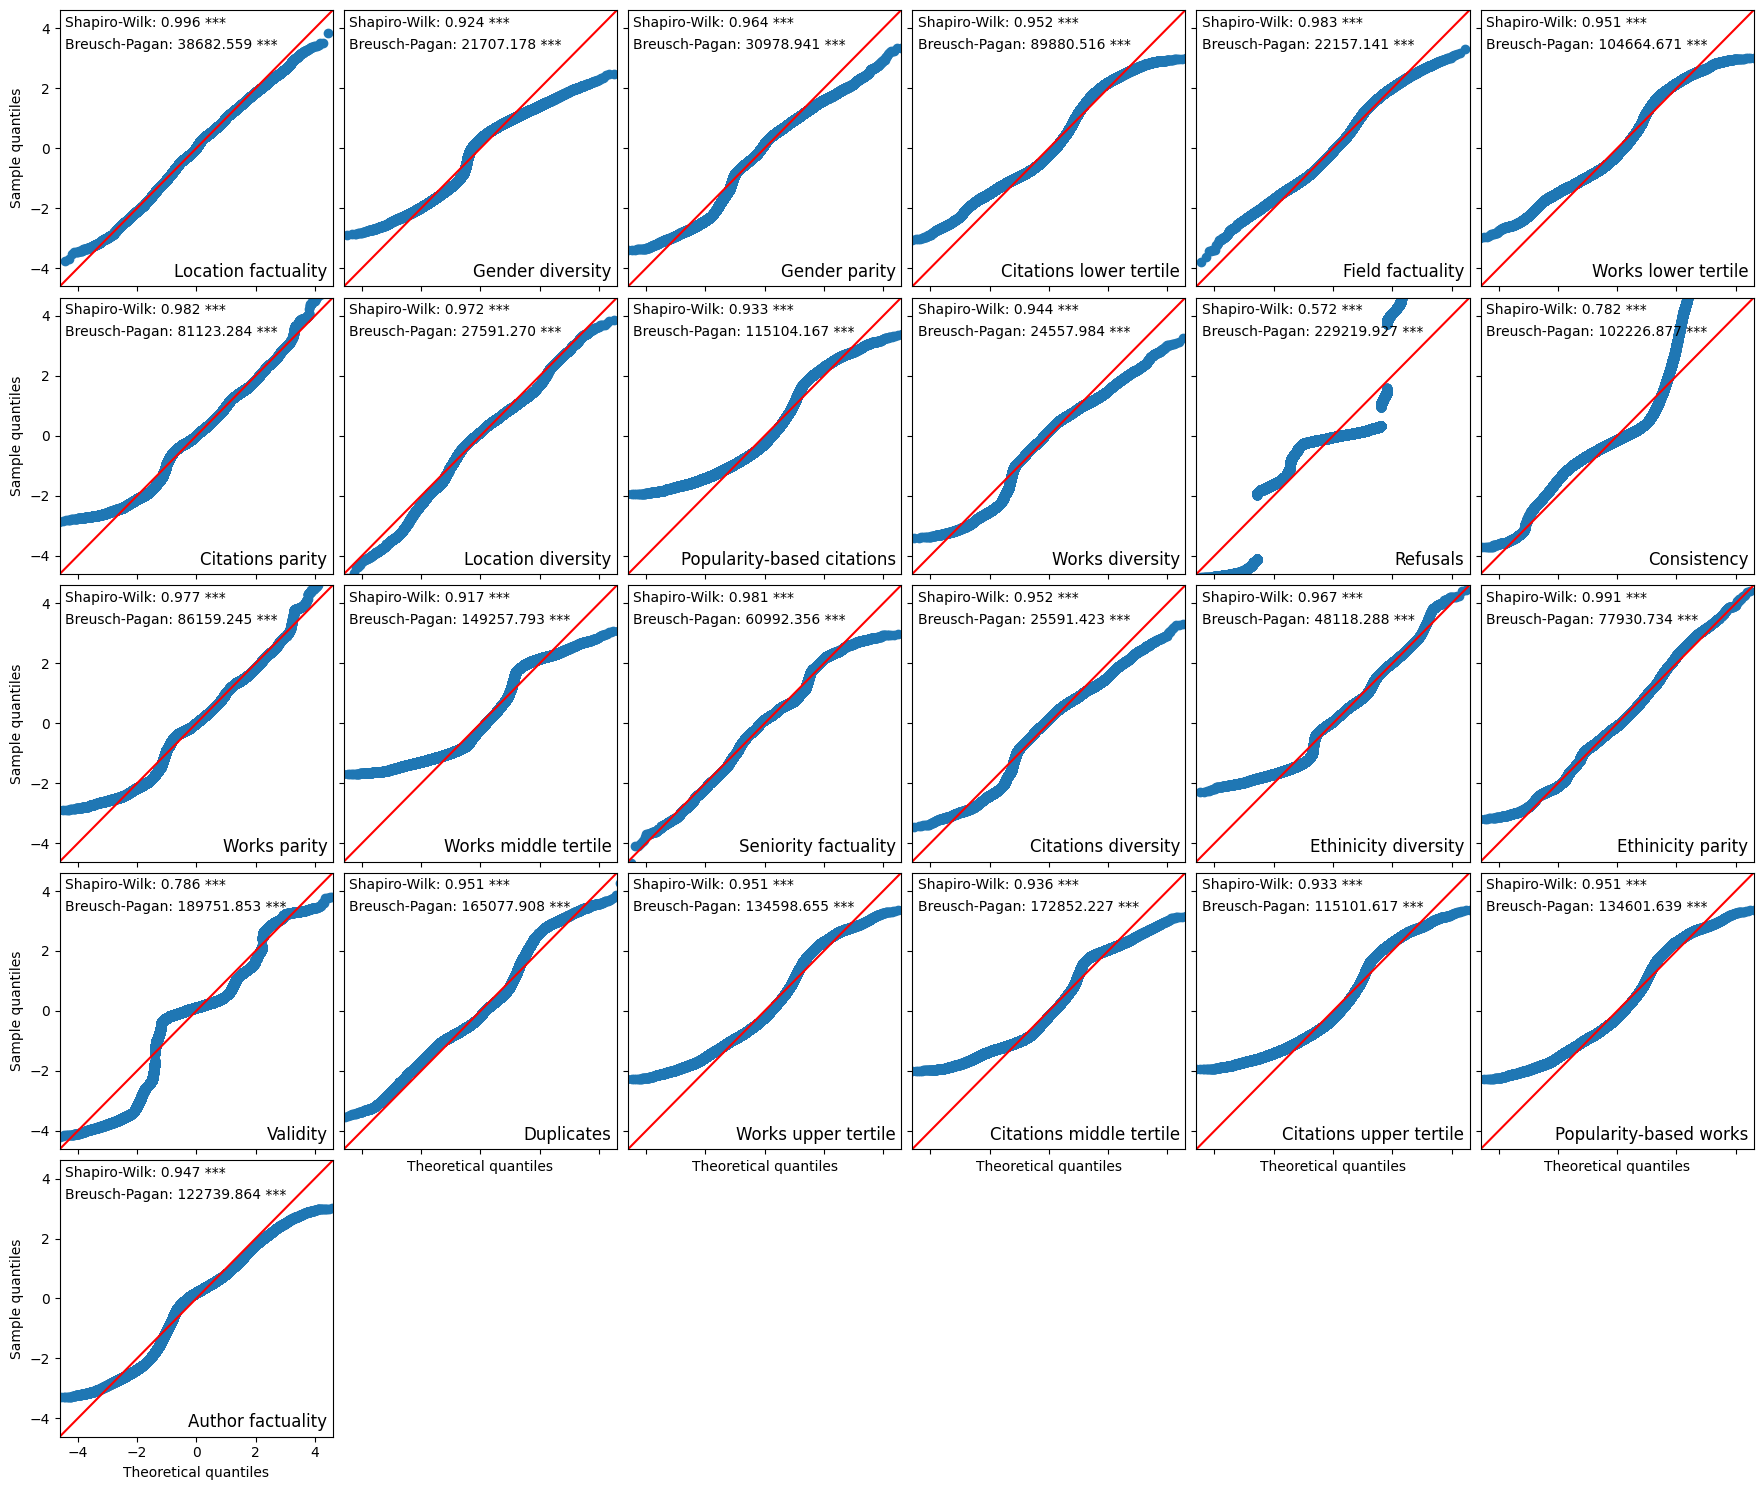

In [17]:
fn_summary_table = ios.path_join(PATH_RESULTS, 'residual_diagnostics.csv')
fn_plot = ios.path_join(PATH_PLOTS, 'residual_diagnostics.pdf')

df_summary_table = plot_residuals_diagnostic(analysis, METRICS_NAME_MAP, fn_summary_table, fn_plot)

In [18]:
def fmt_test(stat, p):
    return f"{stat:.2f}{get_star_suffix(p)}"

latex_df = pd.DataFrame({
    "Metric": df_summary_table["metric"].map(METRICS_NAME_MAP),
    "Shapiro-Wilk test": [
        fmt_test(s, p) for s, p in zip(df_summary_table["shapiro_stat"],
                                       df_summary_table["shapiro_p"])
    ],
    "Breusch-Pagan test": [
        fmt_test(s, p) for s, p in zip(df_summary_table["bp_stat"],
                                       df_summary_table["bp_p"])
    ],
    r"\% fitted values outside [0,1]": df_summary_table["outside_0_1_pct"].round(2)
})

latex_df.columns = [
    "Metric",
    r"\makecell{Shapiro--Wilk\\test\\(statistic)}",
    r"\makecell{Breusch--Pagan\\test\\(statistic)}",
    r"\makecell{\% fitted values\\outside\\$[0,1]$}"
]

latex = latex_df.to_latex(
    index=False,
    escape=False,
    column_format="lccc"
)

print(latex)

\begin{tabular}{lccc}
\toprule
Metric & \makecell{Shapiro--Wilk\\test\\(statistic)} & \makecell{Breusch--Pagan\\test\\(statistic)} & \makecell{\% fitted values\\outside\\$[0,1]$} \\
\midrule
Location factuality & 1.00*** & 38682.56*** & 0.130000 \\
Gender diversity & 0.92*** & 21707.18*** & 0.000000 \\
Gender parity & 0.96*** & 30978.94*** & 0.000000 \\
Citations lower tertile & 0.95*** & 89880.52*** & 0.000000 \\
Field factuality & 0.98*** & 22157.14*** & 0.070000 \\
Works lower tertile & 0.95*** & 104664.67*** & 0.000000 \\
Citations parity & 0.98*** & 81123.28*** & 0.000000 \\
Location diversity & 0.97*** & 27591.27*** & 0.020000 \\
Popularity-based citations & 0.93*** & 115104.17*** & 0.010000 \\
Works diversity & 0.94*** & 24557.98*** & 0.000000 \\
Refusals & 0.57*** & 229219.93*** & 0.360000 \\
Consistency & 0.78*** & 102226.88*** & 0.140000 \\
Works parity & 0.98*** & 86159.25*** & 0.000000 \\
Works middle tertile & 0.92*** & 149257.79*** & 0.000000 \\
Seniority factuality & 0.9

# Plots

## General effects

In [19]:
sns_paper_style(font_scale=1.51)

In [20]:
ROW_GROUPS = PROMPT_VAR_GROUPS
COL_GROUPS = EVALUATION_METRIC_GROUPS

FIG_WIDTH = 15
FIG_HEIGHT = 0.8

In [21]:
NAME_MAP = PLOT_LABELS 

NAME_MAP |= {c:c.replace('factuality_','').replace('bias_','').replace('div_productivity_','').replace('div_','').replace('pct_works_','').replace('pct_citations_','').replace('parity_','').replace('low','T1').replace('med','T2').replace('high','T3').replace('popularity_','').title() 
             for c in ALL_METRICS if c.startswith('parity_') or c.startswith('pct_') or c.startswith('div_') or c.startswith('factuality_') or c.startswith('bias_') or c.startswith('popularity_')}

In [22]:
# Thin reload (no refit, but saved tables are accessible)
# analysis = SensitivityAnalysis.load(PATH_RESULTS)

analysis.effect_sizes(alpha=ALPHA_LEVEL);
p_value_adj = analysis.effects.query("significant==True").p_value_adj.max()
print("max p-value among significant effects:", p_value_adj)

max p-value among significant effects: 0.02006683276171644


In [23]:
analysis.effects.query("significant==True").sort_values('p_value_adj', ascending=False).head(5)

,metric,variable,term,sum_sq,df,F,p_value,omega2,eta2,partial_eta2,kind,N,p_value_adj,significant,correction_method
98,parity_works,role_en,C(role_en),0.365872,1.0,15.569438,0.019565,0.000013,0.000014,0.000028,persona,554237,0.020067,True,fdr_bh
136,parity_ethnicity,language_en,C(language_en),0.573774,2.0,14.151664,0.018616,0.000038,0.000040,0.000054,persona,528668,0.019191,True,fdr_bh
32,factuality_field,language_en,C(language_en),1.543211,2.0,12.909312,0.010021,0.000061,0.000066,0.000116,persona,222887,0.010384,True,fdr_bh
112,factuality_seniority,language_en,C(language_en),0.921143,2.0,12.165581,0.006445,0.000043,0.000046,0.000079,persona,308922,0.006713,True,fdr_bh
122,div_productivity_citations,role_en,C(role_en),1.881321,1.0,26.170589,0.001560,0.000059,0.000061,0.000075,persona,347231,0.001634,True,fdr_bh


Saved plot to: ../../../results/sensitivity_analysis/sensitivity_v9_factualities_v2/plots/sensitivity_by_source_of_variation.pdf


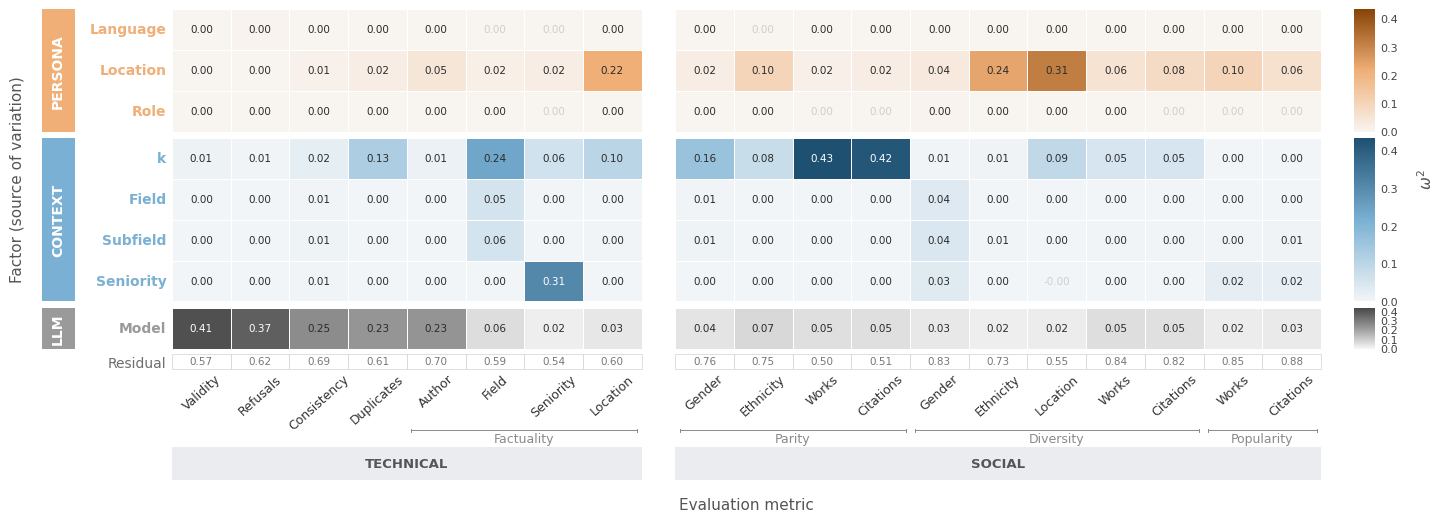

In [26]:

plot = GroupedSensitivityHeatmap.from_long(
    
    ols_results = analysis.results,
    
    anova_df=analysis.effects.query("metric not in @PROMINENCE_METRICS"),
    row_col='variable',
    col_col='metric',
    value_col='omega2',
    pvalue_col='p_value_adj',

    row_groups=ROW_GROUPS,
    col_groups=COL_GROUPS,
    row_group_colors=PROMPT_VAR_COLORS,
    name_map=NAME_MAP, 

    # text — pass None to hide any of these
    figsize=(FIG_WIDTH, 5.2),
    title=None,
    xlabel='Evaluation metric',
    ylabel='Factor (source of variation)',
    annot_threshold=0.0,

    tick_prefix_groups = PREFIX_GROUPS_METRICS,

    # element toggles
    show_colorbar_labels=False,   # the PERSONA / CONTEXT text above each cbar
    show_col_group_labels=True,   # the TECHNICAL / SOCIAL text
    show_row_group_bands=True,    # the orange/blue side bands
    show_colorbars=True,

    # margins (None = auto, computed from what's shown)
    left=None, right=None, top=None, bottom=None,

    significance_style='dim',
    significance_threshold=ALPHA_LEVEL,
)
fig = plot.draw()
fig.tight_layout()
fn = ios.path_join(PATH_PLOTS, 'sensitivity_by_source_of_variation.pdf')
fig.savefig(fn, dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
print(f'Saved plot to: {fn}')


## Main effects

In [ ]:
VARS = {'technical': [c for c in METRIC_TYPES['technical'] if not c.startswith('factuality_')],
        'factuality': [c for c in METRIC_TYPES['technical'] if c.startswith('factuality_')],
        'bias': BIAS_METRICS,                # location bias (issue #36)
        'parity': PARITY_METRICS,
        'diversity': DIVERSITY_METRICS,
        'prominence': PROMINENCE_METRICS,
        'popularity': POPULARITY_METRICS,
        'structural': STRUCTURAL_METRICS,   # connectedness + similarity (Eqs. 6-8)
        }
CCM_XLABEL = 'Effect on metric'

Saved plot to: ../../../results/sensitivity_analysis/sensitivity_v9_factualities_v2/plots/main_effects_by_technical_subset.pdf


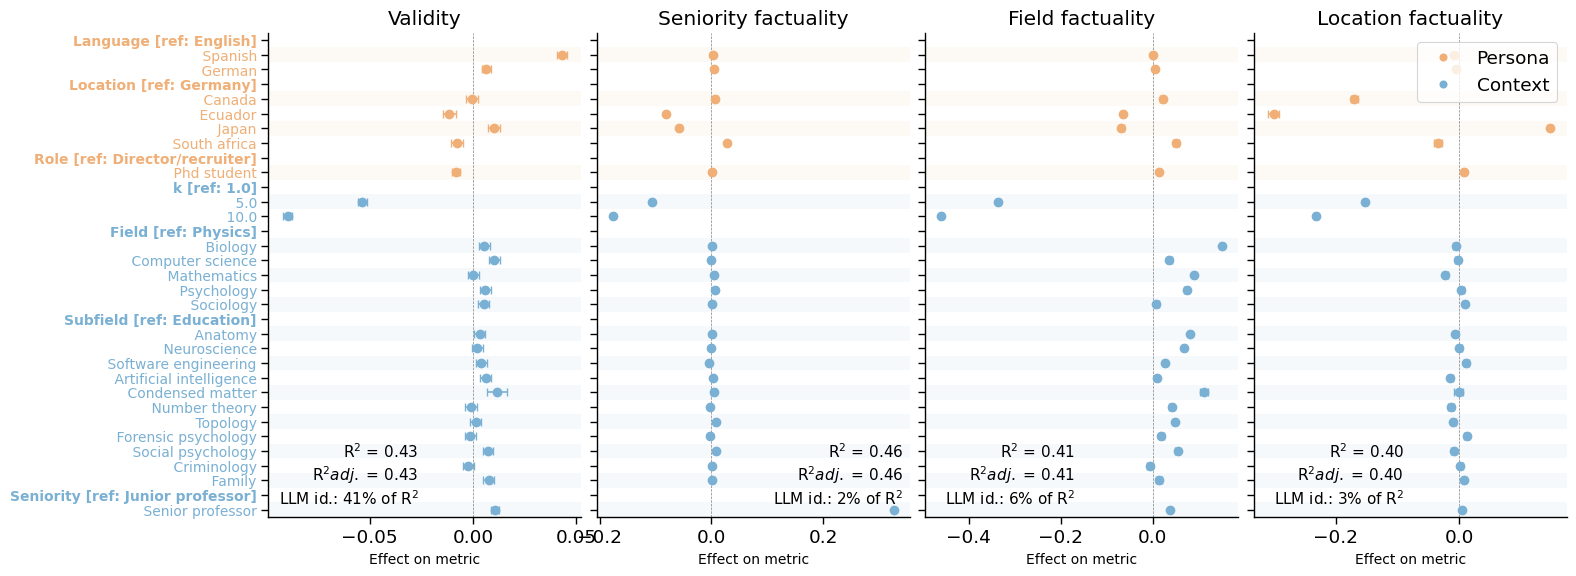

In [28]:
top = ['validity','factuality_seniority','factuality_field', 'bias_location']

nrows = 1
fig,grid = create_grid(analysis.results, metrics=top, nrows=nrows, figsize_per_panel=(4,6))
for metric, obj in grid.items():
    ax = obj['ax']
    model = analysis.results[metric]['m1']
    spec = model.spec
    _ = plot_main_effects(model, 
                         df=df_valid_requests_clean,
                         spec=spec, ax=ax, title = 'Average effect across LLMs', 
                         name_map=NAME_MAP,
                         figsize=(FIG_WIDTH, 6),
                         r2_kwargs={'x': 0.48 if spec.metric in ['validity','factuality_field', 'bias_location'] else 0.98, 'ha': 'right'},
                         )
    ax.set_title(METRICS_NAME_MAP[metric])
    # ax.set_xlabel(CCM_XLABEL if obj['irow'] == nrows-1 else '')
    if obj['icol'] <= obj['ncols']-2:
        ax.legend().remove()
fig.tight_layout()
fig.subplots_adjust(wspace=0.05)
fn = ios.path_join(PATH_PLOTS, f'main_effects_by_technical_subset.pdf')
fig.savefig(fn, dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
print(f'Saved plot to: {fn}')
plt.show()
plt.close()


Saved plot to: ../../../results/sensitivity_analysis/sensitivity_v9_factualities_v2/plots/main_effects_by_social_subset.pdf


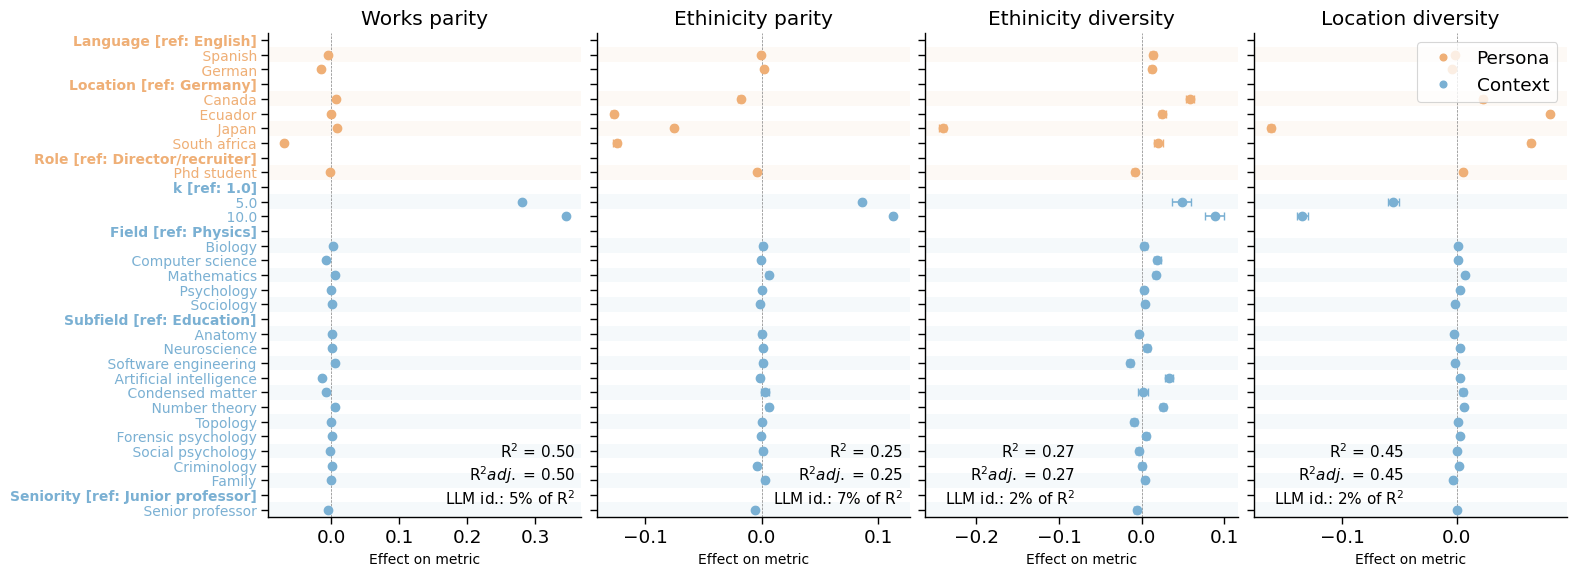

In [29]:
top = ['parity_works','parity_ethnicity','div_ethnicity','div_location']

nrows = 1
fig,grid = create_grid(analysis.results, metrics=top, nrows=nrows, figsize_per_panel=(4,6))
for metric, obj in grid.items():
    ax = obj['ax']
    model = analysis.results[metric]['m1']
    spec = model.spec
    _ = plot_main_effects(model, 
                         df=df_valid_requests_clean,
                         spec=spec, ax=ax, title = 'Average effect across LLMs', 
                         name_map=NAME_MAP,
                         figsize=(FIG_WIDTH, 6),
                         r2_kwargs={'x': 0.98 if spec.metric in ['parity_works','parity_ethnicity'] else 0.48, 'ha': 'right'},
                         )
    ax.set_title(METRICS_NAME_MAP[metric])
    ax.set_xlabel(CCM_XLABEL if obj['irow'] == nrows-1 else '')
    if obj['icol'] <= obj['ncols']-2:
        ax.legend().remove()
fig.tight_layout()
fig.subplots_adjust(wspace=0.05)
fn = ios.path_join(PATH_PLOTS, f'main_effects_by_social_subset.pdf')
fig.savefig(fn, dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
print(f'Saved plot to: {fn}')
plt.show()
plt.close()


Saved plot to: ../../../results/sensitivity_analysis/sensitivity_v9_factualities_v2/plots/main_effects_by_technical_variable.pdf


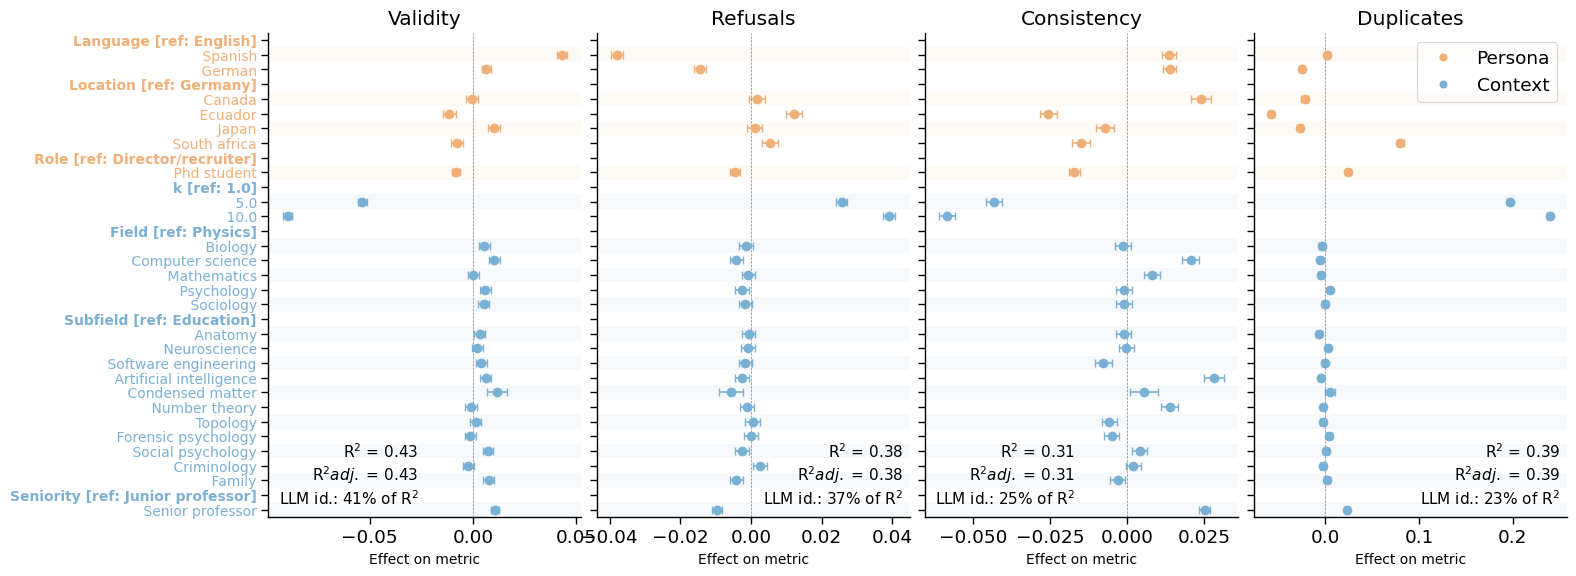

In [30]:
kind = 'technical'
nrows = 1
fig,grid = create_grid(analysis.results, metrics=VARS[kind], nrows=nrows, figsize_per_panel=(4,6))
for metric, obj in grid.items():
    ax = obj['ax']
    model = analysis.results[metric]['m1']
    spec = model.spec
    _ = plot_main_effects(model, 
                         df=df_valid_requests_clean,
                         spec=spec, ax=ax, title = 'Average effect across LLMs', 
                         name_map=NAME_MAP,
                         figsize=(FIG_WIDTH, 6),
                         r2_kwargs={'x': 0.48 if spec.metric in ['validity','consistency'] else 0.98, 'ha': 'right'},
                         )
    ax.set_title(METRICS_NAME_MAP[metric])
    ax.set_xlabel(CCM_XLABEL if obj['irow'] == nrows-1 else '')
    if obj['icol'] <= obj['ncols']-2:
        ax.legend().remove()
fig.tight_layout()
fig.subplots_adjust(wspace=0.05)
fn = ios.path_join(PATH_PLOTS, f'main_effects_by_{kind}_variable.pdf')
fig.savefig(fn, dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
print(f'Saved plot to: {fn}')
plt.show()
plt.close()


Saved plot to: ../../../results/sensitivity_analysis/sensitivity_v9_factualities_v2/plots/main_effects_by_factuality_variable.pdf


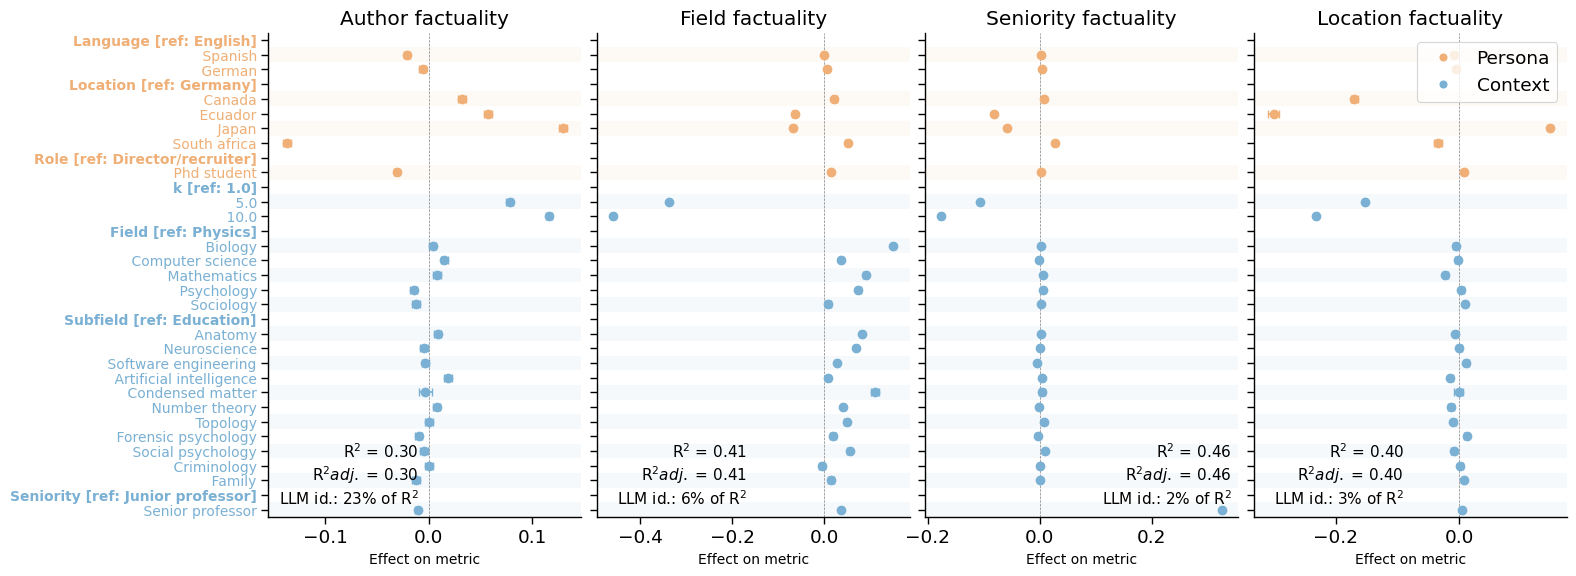

In [31]:
kind = 'factuality'
nrows = 1
fig,grid = create_grid(analysis.results, metrics=VARS[kind], nrows=nrows, figsize_per_panel=(4,6))
for metric, obj in grid.items():
    ax = obj['ax']
    model = analysis.results[metric]['m1']
    spec = model.spec
    _ = plot_main_effects(model, 
                         df=df_valid_requests_clean,
                         spec=spec, ax=ax, title = 'Average effect across LLMs', 
                         name_map=NAME_MAP,
                         figsize=(FIG_WIDTH, 6),
                         r2_kwargs={'x': 0.48 if spec.metric in ['factuality_author','factuality_field'] else 0.98, 'ha': 'right'},
                         )
    ax.set_title(METRICS_NAME_MAP[metric])
    ax.set_xlabel(CCM_XLABEL if obj['irow'] == nrows-1 else '')
    if obj['icol'] <= obj['ncols']-2:
        ax.legend().remove()
fig.tight_layout()
fig.subplots_adjust(wspace=0.05)
fn = ios.path_join(PATH_PLOTS, f'main_effects_by_{kind}_variable.pdf')
fig.savefig(fn, dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
print(f'Saved plot to: {fn}')
plt.show()
plt.close()


In [ ]:
kind = 'bias'
nrows = 1
fig,grid = create_grid(analysis.results, metrics=VARS[kind], nrows=nrows, figsize_per_panel=(FIG_WIDTH/2,6))
for metric, obj in grid.items():
    ax = obj['ax']
    model = analysis.results[metric]['m1']
    spec = model.spec
    _ = plot_main_effects(model,
                         df=df_valid_requests_clean,
                         spec=spec, ax=ax, title = 'Average effect across LLMs',
                         name_map=NAME_MAP,
                         figsize=(FIG_WIDTH, 6),
                         r2_kwargs={'x': 0.98},
                         )
    ax.set_title(METRICS_NAME_MAP[metric])
    ax.set_xlabel(CCM_XLABEL if obj['irow'] == nrows-1 else '')
    if obj['icol'] <= obj['ncols']-2:
        ax.legend().remove()
fig.tight_layout()
fig.subplots_adjust(wspace=0.05)
fn = ios.path_join(PATH_PLOTS, f'main_effects_by_{kind}_variable.pdf')
fig.savefig(fn, dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
print(f'Saved plot to: {fn}')
plt.show()
plt.close()

Saved plot to: ../../../results/sensitivity_analysis/sensitivity_v9_factualities_v2/plots/main_effects_by_parity_variable.pdf


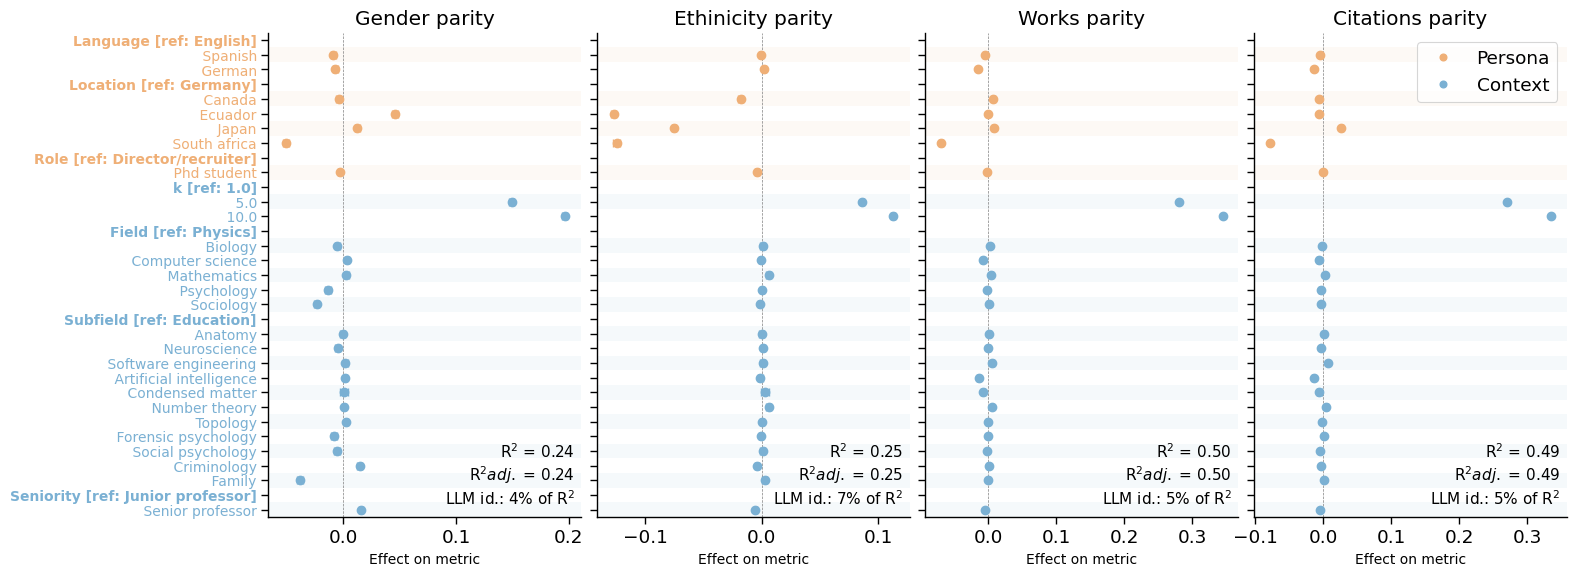

In [32]:
kind = 'parity'
nrows = 1
fig,grid = create_grid(analysis.results, metrics=VARS[kind], nrows=nrows, figsize_per_panel=(4,6))
for metric, obj in grid.items():
    ax = obj['ax']
    model = analysis.results[metric]['m1']
    spec = model.spec
    _ = plot_main_effects(model, 
                         df=df_valid_requests_clean,
                         spec=spec, ax=ax, title = 'Average effect across LLMs', 
                         name_map=NAME_MAP,
                         figsize=(FIG_WIDTH, 6),
                         r2_kwargs={'x':0.98},
                         )
    ax.set_title(METRICS_NAME_MAP[metric])
    ax.set_xlabel(CCM_XLABEL if obj['irow'] == nrows-1 else '')
    if obj['icol'] <= obj['ncols']-2:
        ax.legend().remove()
fig.tight_layout()
fig.subplots_adjust(wspace=0.05)
fn = ios.path_join(PATH_PLOTS, f'main_effects_by_{kind}_variable.pdf')
fig.savefig(fn, dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
print(f'Saved plot to: {fn}')
plt.show()
plt.close()


Saved plot to: ../../../results/sensitivity_analysis/sensitivity_v9_factualities_v2/plots/main_effects_by_diversity_variable.pdf


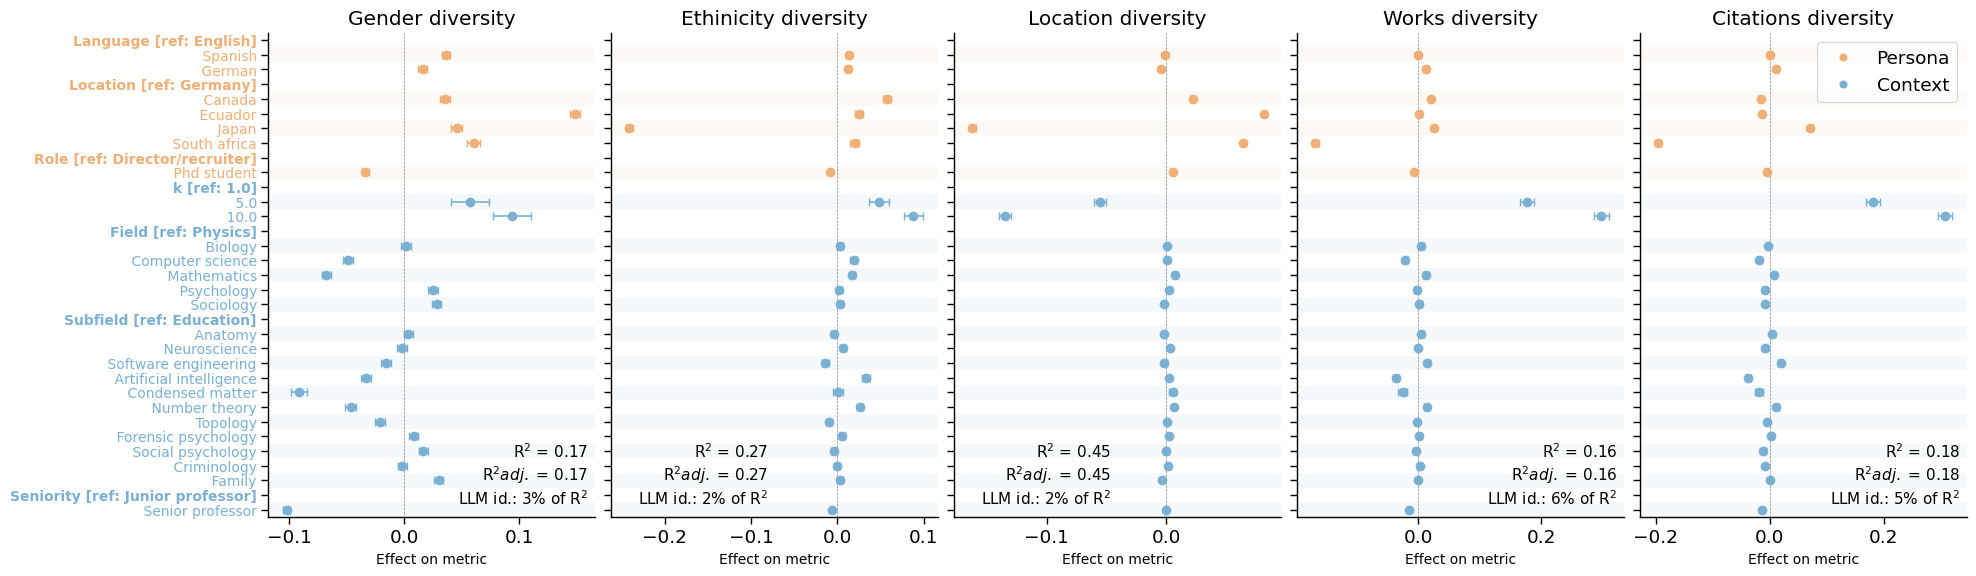

In [33]:
kind = 'diversity'
nrows = 1
fig,grid = create_grid(analysis.results, metrics=VARS[kind], nrows=nrows, figsize_per_panel=(4,6))
for metric, obj in grid.items():
    ax = obj['ax']
    model = analysis.results[metric]['m1']
    spec = model.spec
    _ = plot_main_effects(model, 
                         df=df_valid_requests_clean,
                         spec=spec, ax=ax, title = 'Average effect across LLMs', 
                         name_map=NAME_MAP,
                         figsize=(FIG_WIDTH, 6),
                         r2_kwargs={'x':0.48 if metric in ['div_ethnicity', 'div_location'] else 0.98},
                         )
    ax.set_title(METRICS_NAME_MAP[metric])
    ax.set_xlabel(CCM_XLABEL if obj['irow'] == nrows-1 else '')
    if obj['icol'] <= obj['ncols']-2:
        ax.legend().remove()
fig.tight_layout()
fig.subplots_adjust(wspace=0.05)
fn = ios.path_join(PATH_PLOTS, f'main_effects_by_{kind}_variable.pdf')
fig.savefig(fn, dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
print(f'Saved plot to: {fn}')
plt.show()
plt.close()


Saved plot to: ../../../results/sensitivity_analysis/sensitivity_v9_factualities_v2/plots/main_effects_by_popularity_variable.pdf


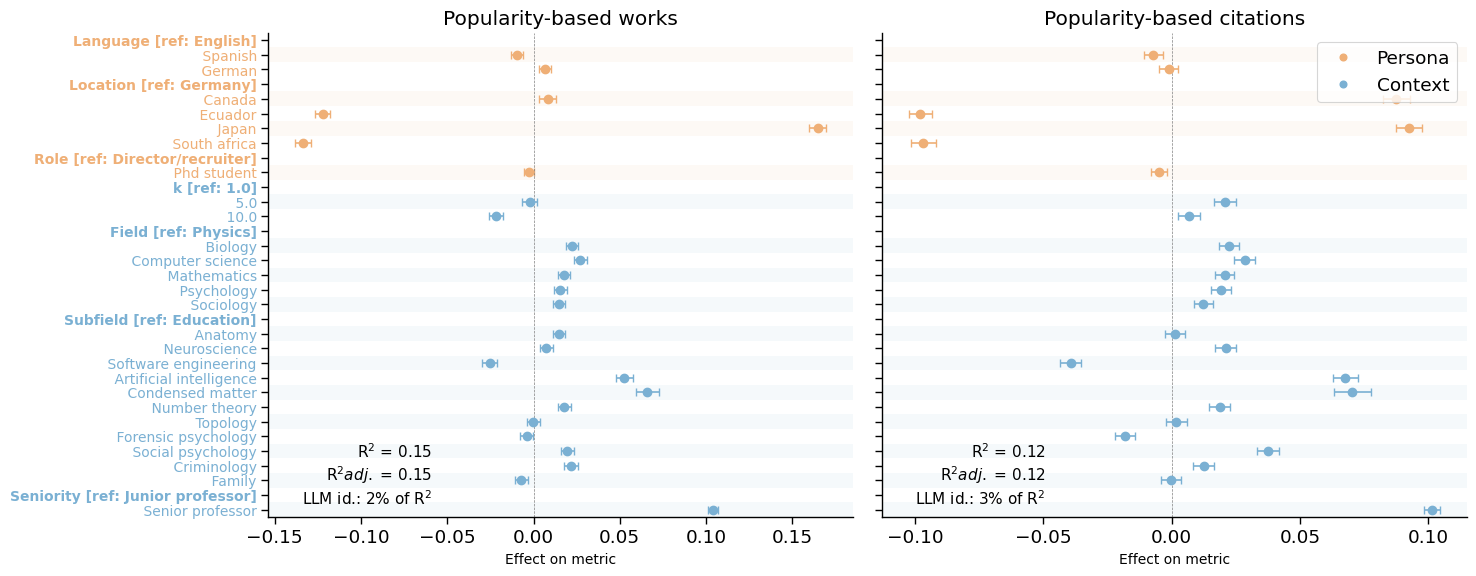

In [34]:
kind = 'popularity'
nrows = 1
fig,grid = create_grid(analysis.results, metrics=VARS[kind], nrows=nrows, figsize_per_panel=(FIG_WIDTH/2,6))
for metric, obj in grid.items():
    ax = obj['ax']
    model = analysis.results[metric]['m1']
    spec = model.spec
    _ = plot_main_effects(model, 
                         df=df_valid_requests_clean,
                         spec=spec, ax=ax, title = 'Average effect across LLMs', 
                         name_map=NAME_MAP,
                         figsize=(FIG_WIDTH, 6),
                         r2_kwargs={'x': 0.28},
                         )
    ax.set_title(METRICS_NAME_MAP[metric])
    ax.set_xlabel(CCM_XLABEL if obj['irow'] == nrows-1 else '')
    if obj['icol'] <= obj['ncols']-2:
        ax.legend().remove()
fig.tight_layout()
fig.subplots_adjust(wspace=0.05)
fn = ios.path_join(PATH_PLOTS, f'main_effects_by_{kind}_variable.pdf')
fig.savefig(fn, dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
print(f'Saved plot to: {fn}')
plt.show()
plt.close()


Saved plot to: ../../../results/sensitivity_analysis/sensitivity_v9_factualities_v2/plots/main_effects_by_prominence_variable.pdf


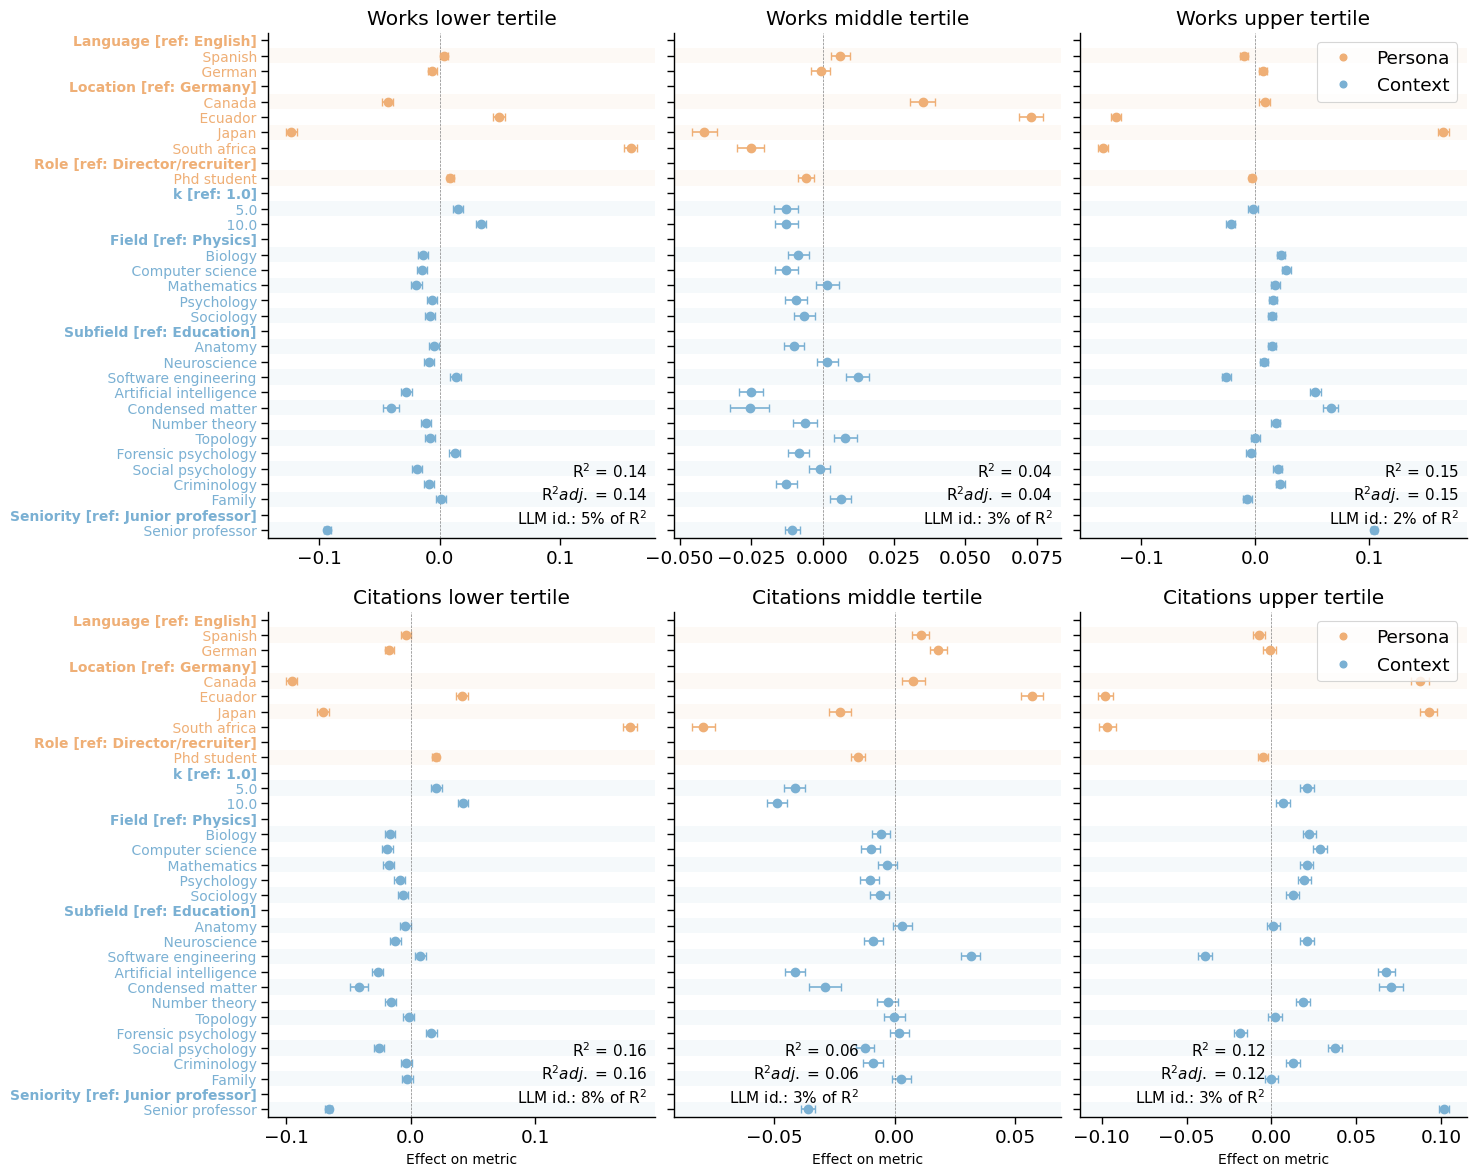

In [35]:
kind = 'prominence'
nrows = 2
fig,grid = create_grid(analysis.results, metrics=VARS[kind], nrows=nrows, figsize_per_panel=(FIG_WIDTH/3,6))
for metric, obj in grid.items():
    ax = obj['ax']
    model = analysis.results[metric]['m1']
    spec = model.spec
    _ = plot_main_effects(model, 
                         df=df_valid_requests_clean,
                         spec=spec, ax=ax, title = 'Average effect across LLMs', 
                         name_map=NAME_MAP,
                         figsize=(FIG_WIDTH, 6),
                         r2_kwargs={'x': 0.48 if spec.metric in ['pct_citations_med', 'pct_citations_high'] else 0.98},
                         )
    ax.set_title(METRICS_NAME_MAP[metric])
    ax.set_xlabel(CCM_XLABEL if obj['irow'] == nrows-1 else '')
    if obj['icol'] <= obj['ncols']-2:
        ax.legend().remove()
fig.tight_layout()
fig.subplots_adjust(wspace=0.05)
fn = ios.path_join(PATH_PLOTS, f'main_effects_by_{kind}_variable.pdf')
fig.savefig(fn, dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
print(f'Saved plot to: {fn}')
plt.show()
plt.close()


In [ ]:
kind = 'structural'
nrows = 1
fig,grid = create_grid(analysis.results, metrics=VARS[kind], nrows=nrows, figsize_per_panel=(FIG_WIDTH/2,6))
for metric, obj in grid.items():
    ax = obj['ax']
    model = analysis.results[metric]['m1']
    spec = model.spec
    _ = plot_main_effects(model,
                         df=df_valid_requests_clean,
                         spec=spec, ax=ax, title = 'Average effect across LLMs',
                         name_map=NAME_MAP,
                         figsize=(FIG_WIDTH, 6),
                         r2_kwargs={'x': 0.98},
                         )
    ax.set_title(METRICS_NAME_MAP[metric])
    ax.set_xlabel(CCM_XLABEL if obj['irow'] == nrows-1 else '')
    if obj['icol'] <= obj['ncols']-2:
        ax.legend().remove()
fig.tight_layout()
fig.subplots_adjust(wspace=0.05)
fn = ios.path_join(PATH_PLOTS, f'main_effects_by_{kind}_variable.pdf')
fig.savefig(fn, dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
print(f'Saved plot to: {fn}')
plt.show()
plt.close()